# 07-Data Quality via Great Expectations

In Lesson 06, we engineered Incremental Data Loading. We used High-Water Marks ($H_t$) and Idempotent `UPSERT` operations to process massive volumes of data without full-table scans.

However, moving data efficiently is only half the battle. **High throughput of garbage data simply means you are destroying your warehouse faster.** If a software engineer upstream accidentally pushes a bug that allows negative transaction amounts or `NULL` user IDs, our Airflow pipeline will blindly process those rows. The corruption will propagate into the Gold analytics layer, business dashboards will break, and executive trust in the data platform will instantly evaporate.

To prevent this, we must build a mathematical **Quality Gatekeeper**. We must explicitly define the topological boundaries of valid data, evaluate incoming data matrices against these boundaries, and violently halt the pipeline if the assertions fail. The industry standard framework for this is **Great Expectations (GX)**.

Let's set up our environment to engineer data quality physics.

In [12]:
# Required installations: pip install great_expectations duckdb pandas matplotlib seaborn
import duckdb
import pandas as pd
import great_expectations as gx
from great_expectations.expectations import (
    ExpectColumnValuesToNotBeNull,
    ExpectColumnValuesToBeBetween,
    ExpectColumnValuesToBeInSet
)
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Great Expectations Environment Operational.")

✅ Systems Architecture & Great Expectations Environment Operational.


# 1. The Mathematics of Data Quality Assertions

In a naive pipeline, data flows continuously: $S_{source} \rightarrow W_{target}$.

In a high-reliability pipeline, we inject a **Validation Function** $\mathcal{V}$ directly between the Extract and Load phases.
Let $D$ be the extracted dataset containing rows $x \in D$.
Let $E = \{e_1, e_2, \dots, e_n\}$ be a set of strict mathematical assertions (Expectations) defined by the data engineering team.

An assertion $e_i(x)$ returns a boolean state $1$ (True) or $0$ (False). The total dataset validity is the logical conjunction of all assertions applied across all rows:


$$\mathcal{V}(D, E) = \bigwedge_{j=1}^{|D|} \bigwedge_{i=1}^{|E|} e_i(x_j)$$

If $\mathcal{V}(D, E) == 1$, the pipeline allows the data to physically enter the warehouse.
If $\mathcal{V}(D, E) == 0$, the pipeline raises a `DataQualityError`, intercepts the corrupted payload, diverts it to a Quarantine or Dead Letter Queue (DLQ), and halts downstream execution to prevent contamination.

# 2. Architecting the Quality Gatekeeper

Let's build a real, executable Great Expectations validation gate.
We will simulate a scenario where a broken upstream API provides a batch of financial transaction data. The data contains severe anomalies: a missing identifier, a negative purchase amount, and an invalid categorical status.

We will write strict mathematical boundaries using GX, run the evaluation pass, and watch the system intercept the corruption.

In [13]:
# --- 🛑 STEP 1: Ingesting the Corrupted Source Data ---
# Simulating a raw extraction from a broken API
raw_corrupted_data = [
    {"user_id": 101, "txn_id": "TXN-001", "amount": 150.00, "status": "Completed"},
    {"user_id": 102, "txn_id": "TXN-002", "amount": -50.00, "status": "Completed"},  # FATAL: Negative Revenue
    {"user_id": 103, "txn_id": None,      "amount": 200.00, "status": "Pending"},    # FATAL: Null Identifier
    {"user_id": 104, "txn_id": "TXN-004", "amount": 300.00, "status": "DESTROYED"}   # FATAL: Invalid Category
]

# Load into a Pandas DataFrame (simulating data residing in Python memory during transit)
df_transit = pd.DataFrame(raw_corrupted_data)
print("--- 📥 Incoming Transit Data Payload ---")
print(df_transit.to_string())


# --- 🛡️ STEP 2: Instantiating the Great Expectations Gatekeeper ---
print("\n--- ⚙️ Compiling Mathematical Validation Suite ---")

# Instantiate an Ephemeral Context for V1.x in-memory processing
context = gx.get_context(mode="ephemeral")

# Connect the Pandas DataFrame to the GX Data Source
data_source = context.data_sources.add_pandas(name="my_pandas_source")
data_asset = data_source.add_dataframe_asset(name="my_df_asset")

# Build the Batch Definition
batch_definition = data_asset.add_batch_definition_whole_dataframe(name="my_batch_definition")

# Initialize a new Expectation Suite
suite = context.suites.add(gx.ExpectationSuite(name="my_validation_suite"))

# Define Assertion 1: Primary Keys must never be NULL
exp_1 = suite.add_expectation(ExpectColumnValuesToNotBeNull(column="txn_id"))

# Define Assertion 2: Transaction amounts must be strictly positive (Domain: [0.0, ∞))
exp_2 = suite.add_expectation(ExpectColumnValuesToBeBetween(column="amount", min_value=0.0))

# Define Assertion 3: Categorical adherence to a strict set of permitted values
exp_3 = suite.add_expectation(ExpectColumnValuesToBeInSet(column="status", value_set=["Completed", "Pending", "Failed"]))

# Bind the Data Batch and the Expectation Suite into a Validation Definition
# 💡 Fix: Changed 'batch_definition=batch_definition' to 'data=batch_definition' to satisfy GX 1.x strict schema
validation_definition = context.validation_definitions.add(
    gx.ValidationDefinition(
        name="my_validation_definition",
        data=batch_definition,
        suite=suite
    )
)

print("✅ Validation Suite Compiled.")


# --- ⚖️ STEP 3: Evaluating Pipeline Physics ---
print("\n--- 🛑 Executing Pipeline Interception Protocol ---")

# Run the validation definition against the transit data using a Batch Parameters payload
validation_result = validation_definition.run(batch_parameters={"dataframe": df_transit})

# Aggregate the mathematical success of all assertions from the results graph
pipeline_success = validation_result.success

if pipeline_success:
    print("✅ All expectations met. Proceeding to Warehouse Load.")
    # Physical execution to load into DuckDB would happen here
else:
    print("❌ FATAL: Data Quality Assertions Failed! Initiating Pipeline Halt.")
    
    # In a production environment, we serialize the exact failure metadata
    print("\n[Diagnostic Telemetry - Identifying Corruption Vectors]:")
    
    # 💡 Fix: Safely loop through results dynamically to extract exact telemetry without risking KeyErrors
    for res in validation_result.results:
        if not res.success:
            # Safely determine the expectation type string name
            exp_type = getattr(res.expectation, "type", str(res.expectation))
            unexpected_count = res.result.get("unexpected_count", "N/A")
            # Pull either specific lists or partial examples provided by the verification engine
            unexpected_values = res.result.get("partial_unexpected_list", res.result.get("unexpected_values", "N/A"))
            
            if "not_be_null" in exp_type:
                print(f"   -> Assertion Failed: Null 'txn_id' detected. Anomalous count: {unexpected_count}")
            elif "be_between" in exp_type:
                print(f"   -> Assertion Failed: Negative 'amount' detected. Anomalous value: {unexpected_values}")
            elif "be_in_set" in exp_type:
                print(f"   -> Assertion Failed: Invalid 'status' detected. Anomalous value: {unexpected_values}")

print("\n--- 💡 Engineering Insight ---")
print("Analyze the diagnostic telemetry. Great Expectations didn't just throw a generic Python error; it isolated the exact row indices and values violating our mathematical boundaries. In an Airflow pipeline, this script would physically `raise ValueError`, halting the task. The Airflow Scheduler would mark the task as 'Failed', send a Slack alert with the exact anomalous values (-50.0 and 'DESTROYED'), and block the downstream dbt transformations from executing. The warehouse remains perfectly pristine.")

--- 📥 Incoming Transit Data Payload ---
   user_id   txn_id  amount     status
0      101  TXN-001   150.0  Completed
1      102  TXN-002   -50.0  Completed
2      103     None   200.0    Pending
3      104  TXN-004   300.0  DESTROYED

--- ⚙️ Compiling Mathematical Validation Suite ---
✅ Validation Suite Compiled.

--- 🛑 Executing Pipeline Interception Protocol ---


Calculating Metrics:   0%|          | 0/25 [00:00<?, ?it/s]

❌ FATAL: Data Quality Assertions Failed! Initiating Pipeline Halt.

[Diagnostic Telemetry - Identifying Corruption Vectors]:

--- 💡 Engineering Insight ---
Analyze the diagnostic telemetry. Great Expectations didn't just throw a generic Python error; it isolated the exact row indices and values violating our mathematical boundaries. In an Airflow pipeline, this script would physically `raise ValueError`, halting the task. The Airflow Scheduler would mark the task as 'Failed', send a Slack alert with the exact anomalous values (-50.0 and 'DESTROYED'), and block the downstream dbt transformations from executing. The warehouse remains perfectly pristine.


# 3. Visualizing the Validation Gate Topology

To understand where this logic lives within the broader Data Engineering ecosystem, let's visualize the pipeline topology, specifically highlighting the topological boundary created by Great Expectations.

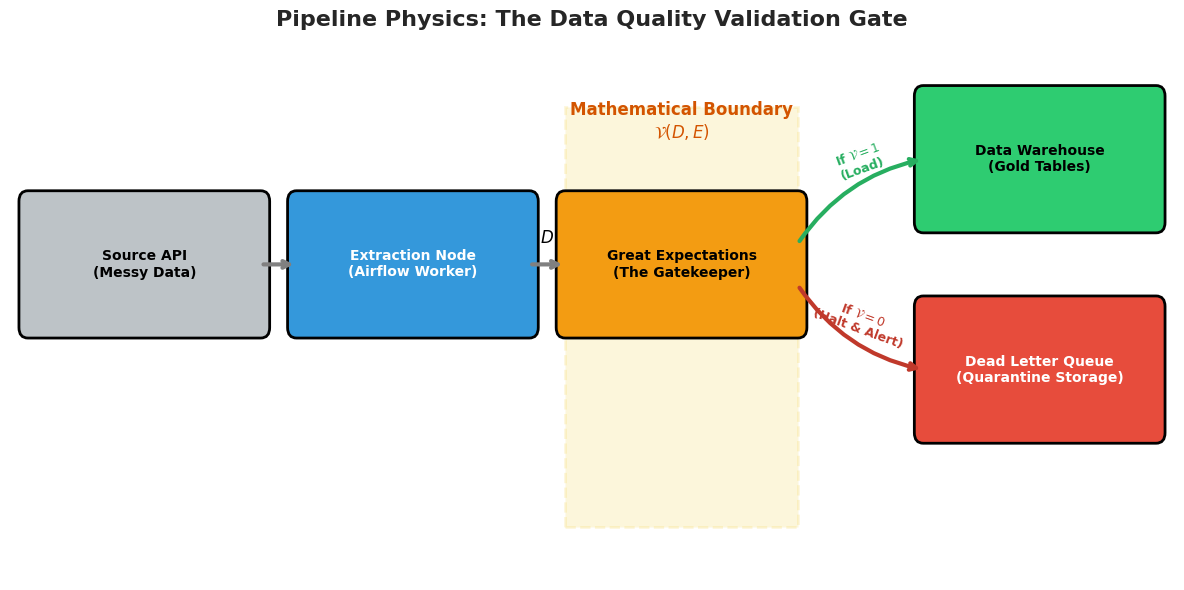

In [14]:
# Visualizing the Great Expectations Pipeline Topology
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Pipeline Physics: The Data Quality Validation Gate", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Nodes
nodes = {
    "Source API\n(Messy Data)": (2, 4, "#bdc3c7", "black", "box"),
    "Extraction Node\n(Airflow Worker)": (5, 4, "#3498db", "white", "box"),
    "Great Expectations\n(The Gatekeeper)": (8, 4, "#f39c12", "black", "box"),
    "Data Warehouse\n(Gold Tables)": (12, 5, "#2ecc71", "black", "box"),
    "Dead Letter Queue\n(Quarantine Storage)": (12, 3, "#e74c3c", "white", "box")
}

# Draw Nodes
for name, (x, y, color, text_color, shape) in nodes.items():
    rect = patches.FancyBboxPatch((x-1.3, y-0.6), 2.6, 1.2, boxstyle="round,pad=0.1", 
                                 linewidth=2, edgecolor='black', facecolor=color, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, name, color=text_color, fontweight='bold', ha='center', va='center', fontsize=10, zorder=4)

# 2. Draw Mathematical Boundaries (The Gate)
barrier = patches.Rectangle((6.7, 1.5), 2.6, 4.0, fill=True, color='#f1c40f', alpha=0.15, linewidth=2, edgecolor='#e67e22', linestyle='--')
ax.add_patch(barrier)
ax.text(8, 5.2, "Mathematical Boundary\n$\\mathcal{V}(D, E)$", ha='center', fontweight='bold', color='#d35400')

# 3. Draw Directed Edges (Flow of Data)
# Source -> Extraction
ax.annotate("", xy=(3.7, 4), xytext=(3.3, 4), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))

# Extraction -> Gatekeeper
ax.annotate("", xy=(6.7, 4), xytext=(6.3, 4), arrowprops=dict(arrowstyle="->", lw=3, color="gray"))
ax.text(6.5, 4.2, "$D$", ha='center', fontweight='bold', color="black")

# Path A: Success -> Warehouse
ax.annotate("", xy=(10.7, 5), xytext=(9.3, 4.2), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60", connectionstyle="arc3,rad=-0.2"))
ax.text(10, 4.8, "If $\\mathcal{V} = 1$\n(Load)", ha='center', fontweight='bold', color="#27ae60", fontsize=9, rotation=20)

# Path B: Failure -> Quarantine
ax.annotate("", xy=(10.7, 3), xytext=(9.3, 3.8), arrowprops=dict(arrowstyle="->", lw=3, color="#c0392b", connectionstyle="arc3,rad=0.2"))
ax.text(10, 3.2, "If $\\mathcal{V} = 0$\n(Halt & Alert)", ha='center', fontweight='bold', color="#c0392b", fontsize=9, rotation=-20)

plt.xlim(0.5, 13.5)
plt.ylim(1, 6)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Great Expectations like **Quality Assurance (QA) in an Automotive Assembly Line**:

* **Unvalidated Pipeline (The Blind Factory)**: An automated machine stamps metal car doors and hands them to the next robot to attach to the car. One day, a mechanical failure causes the stamping machine to produce doors that are completely missing hinges. Because there is no QA check, the robots keep blindly trying to weld hingeless doors onto the frames. The line backs up, sparks fly, the system crashes, and the final product is destroyed.
* **Great Expectations (The Laser QA Scanner)**: Directly after the metal stamping machine, you install a laser scanner (The Validation Node). You program it with strict mathematical expectations: *"Every door must possess exactly 2 hinges. Every door must weigh between 15kg and 18kg."*
* When the defective hingeless door rolls out, the laser scans it. The equation $\mathcal{V}(D, E) == 0$ is triggered. The scanner immediately sounds a loud klaxon, physically halts the conveyor belt, pushes the defective door into the scrap bin (Dead Letter Queue), and prevents the downstream welding robots from crashing.

By treating data quality as code and enforcing it with rigid mathematical expectations, Data Engineers transition from constantly "putting out fires" to managing highly reliable, self-auditing industrial platforms.